In [1]:
import sys

print("Python version:")
print(sys.version)

print("\nPython executable:")
print(sys.executable)

Python version:
3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

Python executable:
c:\Users\AMOGH\Desktop\Nexthikes_Projects\Project6_Sales Forecasting_DL\rossmann-store-sales\Store_Sales_Project\.venv\Scripts\python.exe


In [ ]:
# Enable Logging

import logging
import pandas as pd
from pathlib import Path

# --------------------------------------------------
# Create logs folder if it does not exist
# --------------------------------------------------
LOG_DIR = Path("../logs")
LOG_DIR.mkdir(parents=True, exist_ok=True)

LOG_FILE = LOG_DIR / "store_sales_preprocessing.log"

# --------------------------------------------------
# Create logger
# --------------------------------------------------
logger = logging.getLogger("StoreSales_Preprocessing")
logger.setLevel(logging.DEBUG)

# Prevent duplicate handlers if this cell is run again
if logger.hasHandlers():
    logger.handlers.clear()

# --------------------------------------------------
# Console handler
# --------------------------------------------------
console_handler = logging.StreamHandler()
console_handler.setLevel(logging.DEBUG)

# --------------------------------------------------
# File handler
# --------------------------------------------------
file_handler = logging.FileHandler(
    LOG_FILE,
    mode="a",
    encoding="utf-8"
)
file_handler.setLevel(logging.DEBUG)

# --------------------------------------------------
# Formatter
# --------------------------------------------------
formatter = logging.Formatter(
    "%(asctime)s - %(name)s - %(levelname)s - %(message)s"
)

console_handler.setFormatter(formatter)
file_handler.setFormatter(formatter)

# --------------------------------------------------
# Add handlers
# --------------------------------------------------
logger.addHandler(console_handler)
logger.addHandler(file_handler)

# --------------------------------------------------
# First log message
# --------------------------------------------------
logger.info("Store Sales preprocessing notebook started.")

print(f"Logging enabled: {LOG_FILE.resolve()}")

2026-09-14 17:57:40,761 - StoreSales_Preprocessing - INFO - Store Sales preprocessing notebook started.


In [3]:
# Read CSV files from local data folder

import pandas as pd

logger.info("Starting dataset loading process.")

try:
    # Load datasets
    store = pd.read_csv("../data/store.csv")
    train = pd.read_csv("../data/train.csv")
    test = pd.read_csv("../data/test.csv")

    logger.info("store.csv loaded successfully.")
    logger.info("train.csv loaded successfully.")
    logger.info("test.csv loaded successfully.")

    # Log dataset dimensions
    logger.debug(f"Store dataset shape: {store.shape}")
    logger.debug(f"Train dataset shape: {train.shape}")
    logger.debug(f"Test dataset shape: {test.shape}")

    # Display shapes in notebook
    print("Store shape:", store.shape)
    print("Train shape:", train.shape)
    print("Test shape:", test.shape)

except FileNotFoundError:
    logger.exception(
        "Dataset file not found. Check the ../data/ folder and file names."
    )
    raise

except Exception:
    logger.exception("Unexpected error occurred while loading datasets.")
    raise

2026-09-14 18:01:27,682 - StoreSales_Preprocessing - INFO - Starting dataset loading process.
C:\Users\AMOGH\AppData\Local\Temp\ipykernel_13988\1262776660.py:10: DtypeWarning: Columns (0: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("../data/train.csv")
C:\Users\AMOGH\AppData\Local\Temp\ipykernel_13988\1262776660.py:11: DtypeWarning: Columns (0: Date, 1: StateHoliday) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv("../data/test.csv")
2026-09-14 18:01:28,897 - StoreSales_Preprocessing - INFO - store.csv loaded successfully.
2026-09-14 18:01:28,899 - StoreSales_Preprocessing - INFO - train.csv loaded successfully.
2026-09-14 18:01:28,899 - StoreSales_Preprocessing - INFO - test.csv loaded successfully.
2026-09-14 18:01:28,901 - StoreSales_Preprocessing - DEBUG - Store dataset shape: (1115, 10)
2026-09-14 18:01:28,901 - StoreSales_Preprocessing - DEBUG - Train dataset shape: (1

Store shape: (1115, 10)
Train shape: (1017209, 9)
Test shape: (81233, 8)


In [ ]:
# # 1. Import libraries and load the dataset
# import pandas as pd
# import numpy as np


# # Load datasets
# import io
# import pandas as pd
# store = pd.read_csv(io.BytesIO(uploaded['store.csv']))
# train = pd.read_csv(io.BytesIO(uploaded['train.csv']))
# test = pd.read_csv(io.BytesIO(uploaded['test.csv']))
# #store = pd.read_csv("/mnt/data/store.csv")
# #train = pd.read_csv("/mnt/data/train.csv")
# #test = pd.read_csv("/mnt/data/test.csv")

/tmp/ipykernel_3759/2341847559.py:8: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv(io.BytesIO(uploaded['train.csv']))
/tmp/ipykernel_3759/2341847559.py:9: DtypeWarning: Columns (3,6) have mixed types. Specify dtype option on import or set low_memory=False.
  test = pd.read_csv(io.BytesIO(uploaded['test.csv']))


In [5]:
# Preprocess store.csv to get cleaned_store
# Make a copy

logger.info("Starting missing value handling - store.")
cleaned_store = store.copy()

# CompetitionDistance: fill missing values with median
cleaned_store["CompetitionDistance"] = (
    cleaned_store["CompetitionDistance"]
    .fillna(cleaned_store["CompetitionDistance"].median())
)

# Competition opening information
cleaned_store["CompetitionOpenSinceMonth"] = (
    cleaned_store["CompetitionOpenSinceMonth"].fillna(0)
)

cleaned_store["CompetitionOpenSinceYear"] = (
    cleaned_store["CompetitionOpenSinceYear"].fillna(0)
)

# Promo2-related missing values
cleaned_store["Promo2SinceWeek"] = (
    cleaned_store["Promo2SinceWeek"].fillna(0)
)

cleaned_store["Promo2SinceYear"] = (
    cleaned_store["Promo2SinceYear"].fillna(0)
)

cleaned_store["PromoInterval"] = (
    cleaned_store["PromoInterval"].fillna("None")
)
# Check the result
cleaned_store.isnull().sum()
logger.info("Missing value handling completed - store.")

2026-09-14 18:14:14,150 - StoreSales_Preprocessing - INFO - Starting missing value handling - store.
2026-09-14 18:14:14,189 - StoreSales_Preprocessing - INFO - Missing value handling completed - store.


In [6]:
# Preprocess train.csv to give cleaned_train
# Make a copy
logger.info("Starting missing value handling - train.")
cleaned_train = train.copy()

# Convert Date to datetime
cleaned_train["Date"] = pd.to_datetime(cleaned_train["Date"])

# Extract date features
cleaned_train["Year"] = cleaned_train["Date"].dt.year
cleaned_train["Month"] = cleaned_train["Date"].dt.month
cleaned_train["Day"] = cleaned_train["Date"].dt.day
cleaned_train["WeekOfYear"] = cleaned_train["Date"].dt.isocalendar().week.astype(int)
# Check missing values in train dataset
cleaned_train.isnull().sum()
logger.info("Missing value handling completed - train.")

2026-09-14 18:14:26,797 - StoreSales_Preprocessing - INFO - Starting missing value handling - train.
2026-09-14 18:14:27,541 - StoreSales_Preprocessing - INFO - Missing value handling completed - train.


In [13]:
print("Head:", test.head())
print("\nTest data type:", test.dtypes)
print("\nShape:", test.shape)

print("\nLast 10 rows:")
print(test.tail(10))

print("\nCompletely empty rows:")
print(test.isnull().all(axis=1).sum())

print("\nFirst row containing missing Date:")
print(test[test["Date"].isnull()].head())

print("\nIndex where missing Date starts:")
print(test[test["Date"].isnull()].index.min())

Head:     Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0  1.0    1.0        4.0  17-09-2015   1.0    1.0            0            0.0
1  2.0    3.0        4.0  17-09-2015   1.0    1.0            0            0.0
2  3.0    7.0        4.0  17-09-2015   1.0    1.0            0            0.0
3  4.0    8.0        4.0  17-09-2015   1.0    1.0            0            0.0
4  5.0    9.0        4.0  17-09-2015   1.0    1.0            0            0.0

Test data type: Id               float64
Store            float64
DayOfWeek        float64
Date                 str
Open             float64
Promo            float64
StateHoliday         str
SchoolHoliday    float64
dtype: object

Shape: (81233, 8)

Last 10 rows:
       Id  Store  DayOfWeek Date  Open  Promo StateHoliday  SchoolHoliday
81223 NaN    NaN        NaN  NaN   NaN    NaN          NaN            NaN
81224 NaN    NaN        NaN  NaN   NaN    NaN          NaN            NaN
81225 NaN    NaN        NaN  NaN   NaN 

In [14]:
# Remove completely empty rows
test = test.dropna(how="all").reset_index(drop=True)
print(test.shape)
print(test.isnull().sum())

(41088, 8)
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64


In [15]:
# 4. Preprocess test.csv to give cleaned_test
# Make a copy
logger.info("Starting missing value handling - test.")
cleaned_test = test.copy()

# Convert Date to datetime
## cleaned_test["Date"] = pd.to_datetime(cleaned_test["Date"])
cleaned_test["Date"] = pd.to_datetime(
    cleaned_test["Date"],
    dayfirst=True,
)

# Extract date features
cleaned_test["Year"] = cleaned_test["Date"].dt.year
cleaned_test["Month"] = cleaned_test["Date"].dt.month
cleaned_test["Day"] = cleaned_test["Date"].dt.day
# Extract week of year
## cleaned_test["WeekOfYear"] = cleaned_test["Date"].dt.isocalendar().week.astype(int)
cleaned_test["WeekOfYear"] = (
    cleaned_test["Date"]
    .dt.isocalendar()
    .week
    .fillna(0)
    .astype(int)
)

# Handle missing Open
cleaned_test["Open"] = (
    cleaned_test["Open"]
    .fillna(cleaned_test["Open"].mode()[0])
)
# Check the missing values
cleaned_test.isnull().sum()
logger.info("Missing value handling completed - test.")

2026-09-14 18:18:55,924 - StoreSales_Preprocessing - INFO - Starting missing value handling - test.
2026-09-14 18:18:56,055 - StoreSales_Preprocessing - INFO - Missing value handling completed - test.


In [16]:
print("TEST:")
print(test.shape)
print(test.head())
print("TEST missing values:")
print(test.isnull().sum())

print("CLEANED TEST:")
print(cleaned_test.shape)
print(cleaned_test.head())
print("CLEANED TEST missing values:")
print(cleaned_test.isnull().sum())

TEST:
(41088, 8)
    Id  Store  DayOfWeek        Date  Open  Promo StateHoliday  SchoolHoliday
0  1.0    1.0        4.0  17-09-2015   1.0    1.0            0            0.0
1  2.0    3.0        4.0  17-09-2015   1.0    1.0            0            0.0
2  3.0    7.0        4.0  17-09-2015   1.0    1.0            0            0.0
3  4.0    8.0        4.0  17-09-2015   1.0    1.0            0            0.0
4  5.0    9.0        4.0  17-09-2015   1.0    1.0            0            0.0
TEST missing values:
Id                0
Store             0
DayOfWeek         0
Date              0
Open             11
Promo             0
StateHoliday      0
SchoolHoliday     0
dtype: int64
CLEANED TEST:
(41088, 12)
    Id  Store  DayOfWeek       Date  Open  Promo StateHoliday  SchoolHoliday  \
0  1.0    1.0        4.0 2015-09-17   1.0    1.0            0            0.0   
1  2.0    3.0        4.0 2015-09-17   1.0    1.0            0            0.0   
2  3.0    7.0        4.0 2015-09-17   1.0    1.0       

In [17]:
# 5. Final verification
print("Cleaned Store Shape:", cleaned_store.shape)
print("Cleaned Train Shape:", cleaned_train.shape)
print("Cleaned Test Shape:", cleaned_test.shape)

print("\nMissing values in cleaned_store:")
print(cleaned_store.isnull().sum())

print("\nMissing values in cleaned_train:")
print(cleaned_train.isnull().sum())

print("\nMissing values in cleaned_test:")
print(cleaned_test.isnull().sum())

Cleaned Store Shape: (1115, 10)
Cleaned Train Shape: (1017209, 13)
Cleaned Test Shape: (41088, 12)

Missing values in cleaned_store:
Store                        0
StoreType                    0
Assortment                   0
CompetitionDistance          0
CompetitionOpenSinceMonth    0
CompetitionOpenSinceYear     0
Promo2                       0
Promo2SinceWeek              0
Promo2SinceYear              0
PromoInterval                0
dtype: int64

Missing values in cleaned_train:
Store            0
DayOfWeek        0
Date             0
Sales            0
Customers        0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
Year             0
Month            0
Day              0
WeekOfYear       0
dtype: int64

Missing values in cleaned_test:
Id               0
Store            0
DayOfWeek        0
Date             0
Open             0
Promo            0
StateHoliday     0
SchoolHoliday    0
Year             0
Month            0
Day              0
WeekOfYe

In [18]:
# Merging:
logger.info("Merging store data with train and test datasets.")
store_train = cleaned_train.merge(
    cleaned_store,
    on="Store",
    how="left"
)

store_test = cleaned_test.merge(
    cleaned_store,
    on="Store",
    how="left"
)

logger.info("Dataset merging completed.")
logger.debug(f"Merged train shape: {store_train.shape}")
logger.debug(f"Merged test shape: {store_test.shape}")

2026-09-14 18:19:16,103 - StoreSales_Preprocessing - INFO - Merging store data with train and test datasets.
2026-09-14 18:19:16,304 - StoreSales_Preprocessing - INFO - Dataset merging completed.
2026-09-14 18:19:16,304 - StoreSales_Preprocessing - DEBUG - Merged train shape: (1017209, 22)
2026-09-14 18:19:16,321 - StoreSales_Preprocessing - DEBUG - Merged test shape: (41088, 21)


In [19]:
print(store_train.shape)
print(store_test.shape)

(1017209, 22)
(41088, 21)


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns

# Basic look at merged data
print(store_train.head())

print("\nShape:")
print(store_train.shape)

print("\nData Types:")
print(store_train.dtypes)

print("\nMissing Values:")
print(store_train.isnull().sum())

print("\nSummary Statistics:")
print(store_train.describe())

   Store  DayOfWeek       Date  Sales  Customers  Open  Promo StateHoliday  \
0      1          5 2015-07-31   5263        555     1      1            0   
1      2          5 2015-07-31   6064        625     1      1            0   
2      3          5 2015-07-31   8314        821     1      1            0   
3      4          5 2015-07-31  13995       1498     1      1            0   
4      5          5 2015-07-31   4822        559     1      1            0   

   SchoolHoliday  Year  ...  WeekOfYear  StoreType  Assortment  \
0              1  2015  ...          31          c           a   
1              1  2015  ...          31          a           a   
2              1  2015  ...          31          a           a   
3              1  2015  ...          31          c           c   
4              1  2015  ...          31          a           a   

  CompetitionDistance CompetitionOpenSinceMonth  CompetitionOpenSinceYear  \
0              1270.0                       9.0          

2026-09-14 18:25:22,676 - StoreSales_Preprocessing - INFO - Starting Exploratory Data Analysis (EDA).


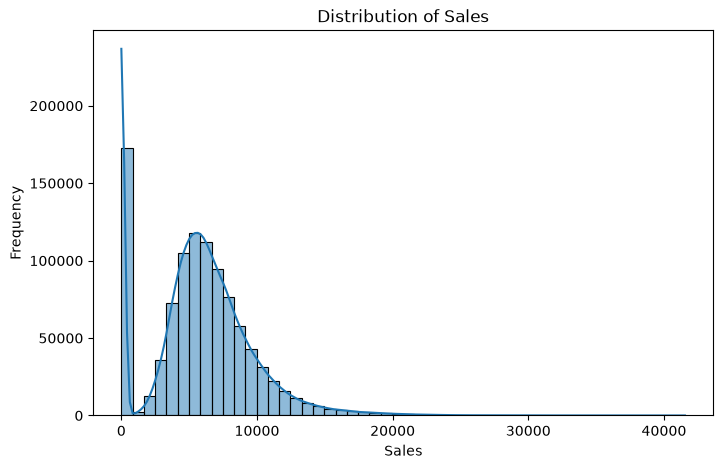

In [23]:
# EDA
# Sales Distributions
logger.info("Starting Exploratory Data Analysis (EDA).")
plt.figure(figsize=(8, 5))
sns.histplot(
    store_train["Sales"],
    bins=50,
    kde=True
)
plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Insights: The Sales variable shows a positively skewed distribution.
# Most sales values are concentrated in the moderate range, while a small number of observations show very high sales, creating a long right tail.
# A significant peak at zero is also observed, which may mainly represent days when stores were closed.
# High sales values should be investigated with promotional and holiday-related features before considering them as outliers.

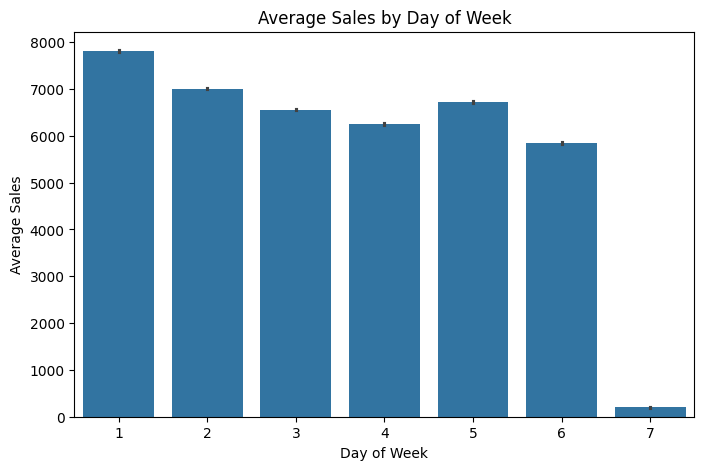

In [ ]:
# Sales by DayofWeek
plt.figure(figsize=(8, 5))
sns.barplot(
    data=store_train,
    x="DayOfWeek",
    y="Sales"
)
plt.title("Average Sales by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

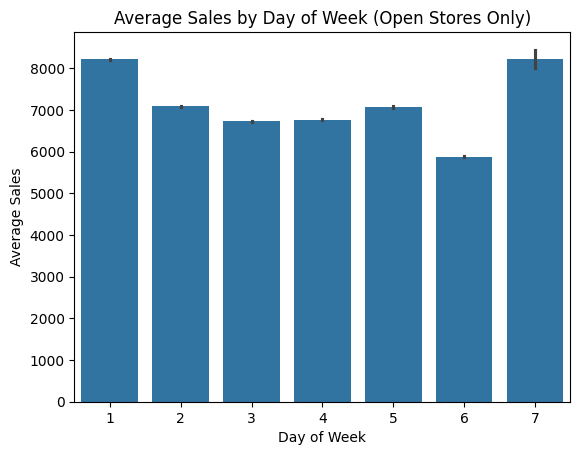

In [ ]:
# Average sales only when stores are open:
open_stores = store_train[store_train["Open"] == 1]

sns.barplot(
    data=open_stores,
    x="DayOfWeek",
    y="Sales"
)

plt.title("Average Sales by Day of Week (Open Stores Only)")
plt.xlabel("Day of Week")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# Insight:
 # Average sales vary significantly across the days of the week.
 # Monday records the highest average sales, while sales generally decline toward the weekend, with a slight increase on Friday.
 # Sunday shows exceptionally low average sales, which is likely influenced by store closures.
 # This indicates that DayOfWeek and Open are important variables for understanding and predicting store sales.

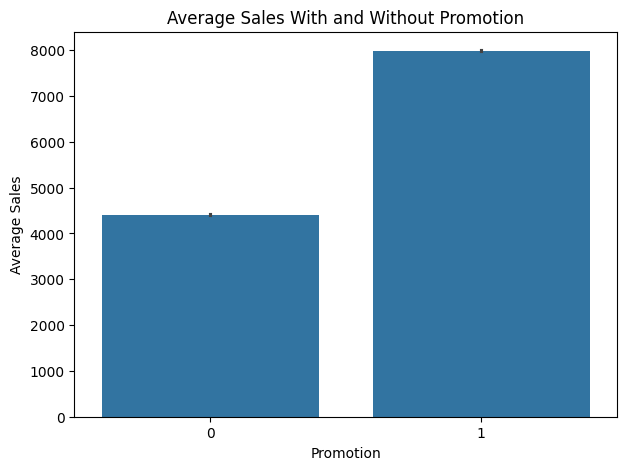

In [ ]:
# Effect of Promotion on Sales
# 0 = No Promotion, 1 = Promotion Active
plt.figure(figsize=(7, 5))

sns.barplot(
    data=store_train,
    x="Promo",
    y="Sales"
)
plt.title("Average Sales With and Without Promotion")
plt.xlabel("Promotion")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# Insights:
# Promotional activities have a strong positive association with store sales.
# Average sales are approximately 8,000 during promotional periods compared with about 4,400 without promotions.
# This indicates that promotion is an important factor influencing sales and is likely to be a valuable feature for sales forecasting.

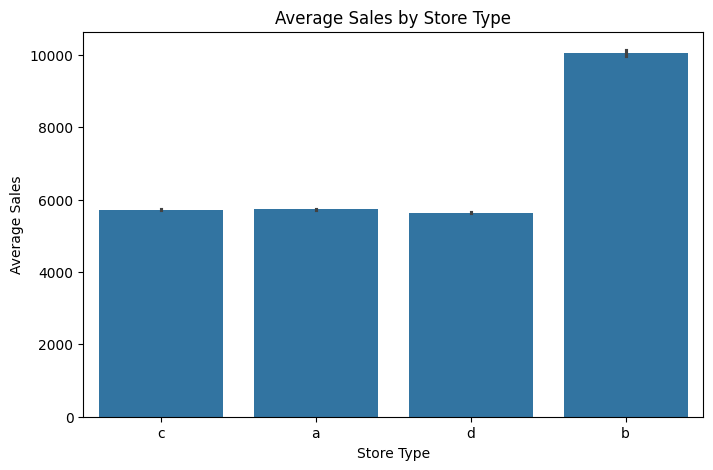

In [ ]:
# Sales by Store Type
plt.figure(figsize=(8, 5))

sns.barplot(
    data=store_train,
    x="StoreType",
    y="Sales"
)
plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# Insight:
# Store Type b records the highest average sales at approximately 10,000, considerably outperforming Store Types a, c, and d, whose average sales are around 5,600–5,800.
# This indicates that store type has a noticeable relationship with sales, with Type b stores showing particularly strong sales performance.
# Therefore, StoreType may be an important feature for sales forecasting.

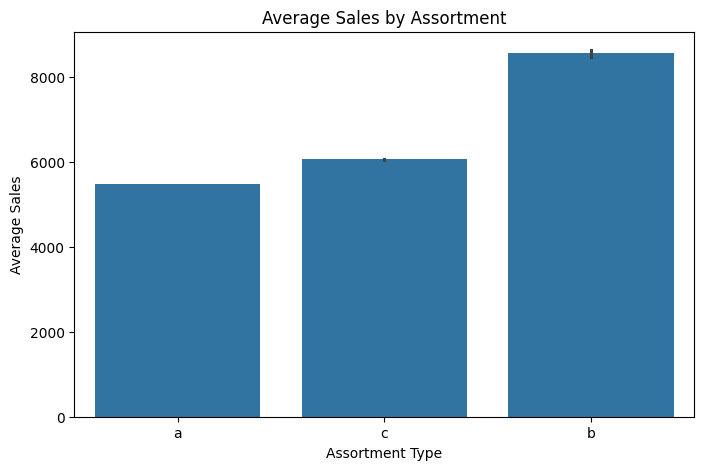

In [ ]:
# Sales by Assortment Type
plt.figure(figsize=(8, 5))

sns.barplot(
    data=store_train,
    x="Assortment",
    y="Sales"
)
plt.title("Average Sales by Assortment")
plt.xlabel("Assortment Type")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
#Insights:
# Assortment Type b records the highest average sales at approximately 8,500, followed by Type c at around 6,100 and Type a at about 5,500.
# This suggests that stores with Assortment Type b tend to generate stronger sales performance.
# Hence, assortment type is an important factor to consider when analysing and forecasting store sale

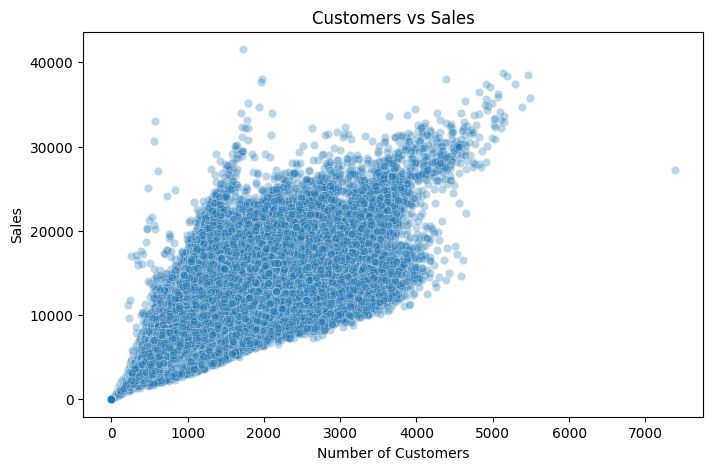

In [ ]:
# Customers vs Sales
plt.figure(figsize=(8, 5))

sns.scatterplot(
    data=store_train,
    x="Customers",
    y="Sales",
    alpha=0.3
)
plt.title("Customers vs Sales")
plt.xlabel("Number of Customers")
plt.ylabel("Sales")
plt.show()


In [ ]:
# Insight:
# The scatter plot indicates a strong positive relationship between customer count and sales, with sales generally increasing as the number of customers increases.
# This suggests that customer footfall is a major factor associated with store revenue.
# However, variations in sales at similar customer levels indicate that other factors such as promotions, store type, and assortment may also influence customer spending.
# Since customer information is unavailable in the test dataset, it should be used for EDA but excluded from the final forecasting model.

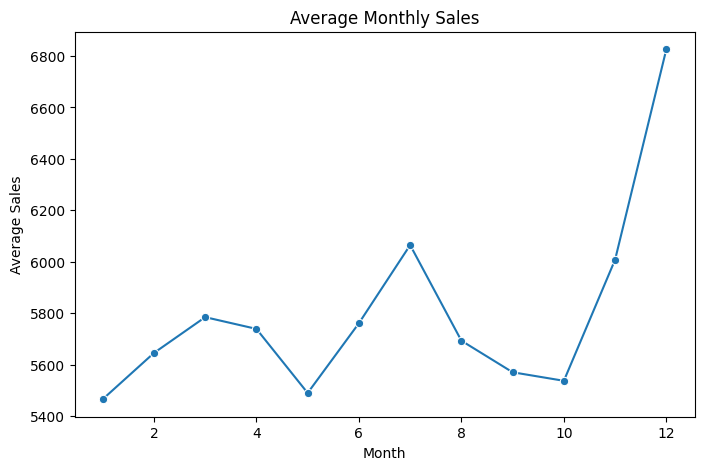

In [ ]:
# Monthly Sales Trend
monthly_sales = (
    store_train
    .groupby("Month")["Sales"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8, 5))
sns.lineplot(
    data=monthly_sales,
    x="Month",
    y="Sales",
    marker="o"
)
plt.title("Average Monthly Sales")
plt.xlabel("Month")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# Insight: Insight: Average sales exhibit a seasonal pattern throughout the year.
# December records the highest average sales, followed by a notable peak in July, while January and May show relatively lower sales.
# The sharp increase toward November and December indicates stronger year-end demand.
# Therefore, the Month feature can provide valuable information for predicting sales and planning inventory, staffing and promotional activities.

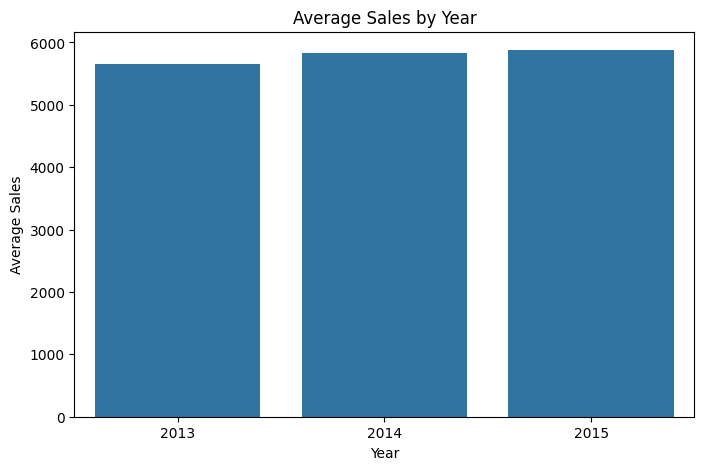

In [ ]:
# Year-wise Sales
yearly_sales = (
    store_train
    .groupby("Year")["Sales"]
    .mean()
    .reset_index()
)
plt.figure(figsize=(8, 5))
sns.barplot(
    data=yearly_sales,
    x="Year",
    y="Sales"
)
plt.title("Average Sales by Year")
plt.xlabel("Year")
plt.ylabel("Average Sales")
plt.show()

In [ ]:
# Insight:
# Average sales show a slight upward trend from 2013 to 2015.
# Sales increased from approximately 5,650 in 2013 to about 5,880 in 2015, indicating relatively stable performance with modest growth over the observed period.
# However, year-to-year differences are considerably smaller than the variations observed for factors such as promotions and store characteristics.

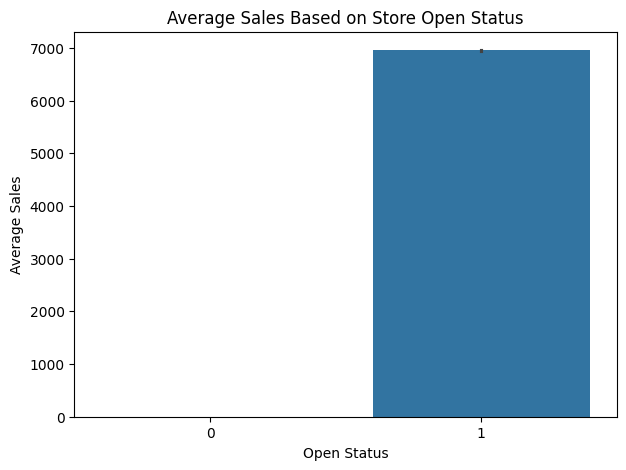

In [ ]:
# Open vs Sales
plt.figure(figsize=(7, 5))

sns.barplot(
    data=store_train,
    x="Open",
    y="Sales"
)

plt.title("Average Sales Based on Store Open Status")
plt.xlabel("Open Status")
plt.ylabel("Average Sales")

plt.show()

In [ ]:
# Insight:
# Store operating status has a major relationship with sales.
# Closed stores record approximately zero sales, whereas open stores generate average sales of around 7,000.
# This confirms that the Open variable is an important predictor of sales and also explains many of the zero values observed in the overall sales distribution.

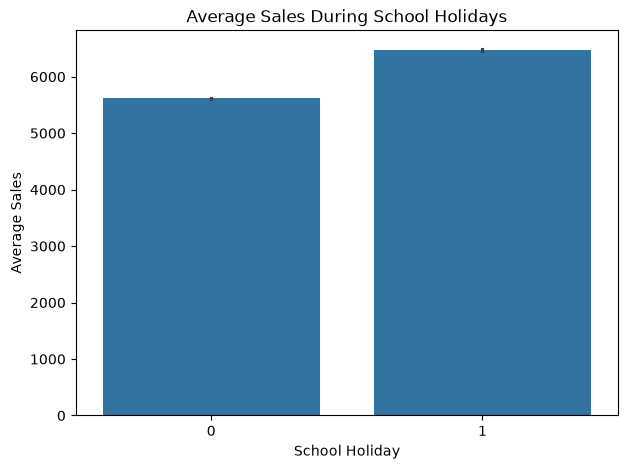

2026-09-14 18:28:06,477 - StoreSales_Preprocessing - INFO - Exploratory Data Analysis (EDA) completed successfully.


In [24]:
# School Holiday vs Sales
plt.figure(figsize=(7, 5))

sns.barplot(
    data=store_train,
    x="SchoolHoliday",
    y="Sales"
)
plt.title("Average Sales During School Holidays")
plt.xlabel("School Holiday")
plt.ylabel("Average Sales")
plt.show()
logger.info("Exploratory Data Analysis (EDA) completed successfully.")

In [ ]:
# Insight:
# Average sales are higher during school holidays, increasing from approximately 5,600 on non-school-holiday days to around 6,500 on school-holiday days.
# This indicates that school-holiday periods are associated with increased sales activity.
# Therefore, SchoolHoliday can be considered a useful feature for sales forecasting and business planning.

In [25]:
# Correlations:
# Select numerical columns
logger.debug("Generating correlation analysis for numerical features.")
numeric_columns = store_train.select_dtypes(
    include=["int64", "float64", "int32", "float32"]
)
sales_correlation = (numeric_columns.corr()["Sales"].sort_values(ascending=False))
print(sales_correlation)

2026-09-14 18:28:16,988 - StoreSales_Preprocessing - DEBUG - Generating correlation analysis for numerical features.


Sales                        1.000000
Customers                    0.894711
Open                         0.678472
Promo                        0.452345
SchoolHoliday                0.085124
WeekOfYear                   0.052946
Month                        0.048768
Year                         0.023519
Store                        0.005126
CompetitionOpenSinceYear     0.002749
Day                         -0.011612
CompetitionOpenSinceMonth   -0.012431
CompetitionDistance         -0.018869
Promo2SinceWeek             -0.044143
Promo2                      -0.091040
Promo2SinceYear             -0.091056
DayOfWeek                   -0.462125
Name: Sales, dtype: float64


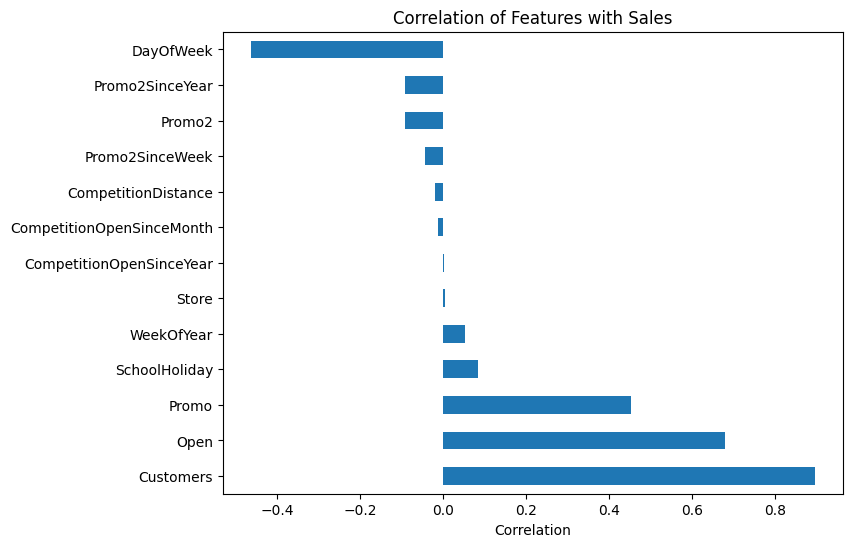

In [ ]:
# Corellation Visualization:
plt.figure(figsize=(8, 6))
sales_correlation.drop("Sales").plot(
    kind="barh"
)
plt.title("Correlation of Features with Sales")
plt.xlabel("Correlation")
plt.show()


In [ ]:
# Insight:
# Customer count shows the strongest positive correlation with Sales, followed by store opening status and promotions.
# DayOfWeek shows a moderate negative correlation, indicating that sales vary considerably across the week.
# Most competition and Promo2-related variables have relatively weak individual linear correlations with Sales.
# However, these features should not be discarded solely on the basis of correlation, as they may provide useful nonlinear or interaction effects in machine-learning models.
# Customers, although highly correlated with Sales, should be excluded from the final forecasting model because it is unavailable in the test dataset.

In [26]:
# Final validation after merging

train_missing_promo = store_train["PromoInterval"].isnull().sum()
test_missing_promo = store_test["PromoInterval"].isnull().sum()

print("Missing PromoInterval - Train:", train_missing_promo)
print("Missing PromoInterval - Test:", test_missing_promo)

logger.debug(
    f"Missing PromoInterval values - "
    f"Train: {train_missing_promo}, Test: {test_missing_promo}"
)

2026-09-14 18:40:20,185 - StoreSales_Preprocessing - DEBUG - Missing PromoInterval values - Train: 0, Test: 0


Missing PromoInterval - Train: 0
Missing PromoInterval - Test: 0


In [ ]:
# Save merged and cleaned datasets

logger.info("Saving feature-engineered datasets.")

store_train.to_csv("../data/store_train.csv", index=False)
store_test.to_csv("../data/store_test.csv", index=False)

print("Files saved successfully.")
logger.info("Merged cleaned datasets saved successfully.")

Files saved successfully.
